# Deep Learning: The Math of Convolutions

In Lesson 01, we successfully translated physical light into multi-dimensional PyTorch Tensors. Our images are now floating-point matrices.

Now, we face a critical engineering problem: How do we teach a neural network to actually "see" patterns in these numbers?

Our instinct from standard Deep Learning would be to use a Multi-Layer Perceptron (MLP) consisting of `nn.Linear` layers. But applying an MLP to an image introduces a catastrophic mathematical and physical failure. We need a new mathematical operation—one that understands the physical geometry of space. We need the **Convolution**.

Let's set up our PyTorch environment to master spatial mathematics on real image data.

In [3]:
import torch
import torch.nn.functional as F
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Spatial Mathematics Environment Ready.")

✅ PyTorch Spatial Mathematics Environment Ready.


# 1. The Fatal Flaw of the MLP (The Dense Trap)

If we want to pass a 2D image into a standard `nn.Linear` layer, we must first "flatten" the 2D matrix into a 1D array.

This triggers two massive architectural failures:

1. **Destruction of Spatial Context**: The physical universe is locally correlated. Pixels that are physically next to each other usually belong to the same object. If you flatten a 2D image, a pixel at the top-right and a pixel at the bottom-left are suddenly pushed thousands of numbers apart in the 1D vector. The network completely loses the geometric reality of the 2D plane.
2. **The Parameter Explosion**: Our `data.camera()` image is $512 \times 512$ pixels. Flattened, that is an input vector of $262,144$ numbers. If your first hidden layer has just $1,000$ neurons, that single layer requires mathematically mapping every input to every neuron: $262,144 \times 1,000 =$ **262 Million Weights**. The GPU will instantly run out of memory, and the network will violently overfit to the training data.

# 2. The Convolution Operation (Cross-Correlation)

Instead of looking at the entire image at once with 262 million weights, we introduce a **Kernel** (also called a Filter).

A Kernel is a tiny, mathematically learnable matrix—usually $3 \times 3$ or $5 \times 5$. Instead of flattening the image, we physically *slide* this tiny kernel across the 2D image, left-to-right, top-to-bottom. At every step, we calculate the mathematical dot product between the kernel and the patch of pixels it is currently sitting on top of.

*(Note: In rigorous mathematics, this sliding dot product is actually called **Cross-Correlation**. True mathematical convolution requires flipping the kernel 180 degrees first. In Deep Learning, we skip the flip to save GPU cycles, but we still conventionally call it a Convolution).*

$$S(i, j) = (I * K)(i, j) = \sum_m \sum_n I(i+m, j+n) K(m, n)$$


*(Where $I$ is the Image matrix, $K$ is the Kernel matrix, and $S$ is the output Feature Map).*

**The Genius of Weight Sharing:** Because a $3 \times 3$ kernel only has **9 weights**, and we reuse those exact same 9 weights to scan the *entire* image, we have completely solved the Parameter Explosion!

# 3. Padding ($P$) and Stride ($S$)

When you slide a $3 \times 3$ kernel over a $512 \times 512$ image, the output does not remain $512 \times 512$. It shrinks slightly because the center of the kernel cannot reach the absolute edge pixels without falling off the image. If you pass an image through 50 convolution layers, the image will mathematically shrink until it disappears into nothing.

To control the spatial dimensions of our data, we engineer two hyperparameters:

* **Stride ($S$)**: The step size of the slide. A stride of $1$ means the kernel moves 1 pixel at a time. A stride of $2$ means the kernel jumps 2 pixels, effectively cutting the output image resolution mathematically in half.
* **Padding ($P$)**: To prevent the image from shrinking at $S=1$, we artificially wrap the perimeter of the original image in a border of absolute zeros (Zero-Padding). This gives the kernel room to slide over the edge pixels without shrinking the output matrix.

### The Most Important Formula in Computer Vision

When you design deep architectures, you must mathematically calculate the exact size of the matrix coming out of a convolution layer to ensure it perfectly connects to the next layer. Let $W$ be the input width, $K$ be the kernel size, $P$ be padding, and $S$ be stride.

$$O_{size} = \lfloor \frac{W - K + 2P}{S} \rfloor + 1$$

# 4. Extracting Features from a Real Photograph

In a real neural network, the numbers inside the $3 \times 3$ kernel start as random noise and are learned via Backpropagation. However, to prove the mathematics of feature extraction, we can manually hardcode a kernel designed by human mathematicians: the **Sobel Filter**.

Let's load our cameraman, convert him to a PyTorch tensor, and mathematically slide vertical and horizontal edge-detection kernels across his pixels.

--- 📥 Loading and Formatting Image Tensor ---
Input Tensor Shape: torch.Size([1, 1, 512, 512]) [B, C, H, W]

--- ⚙️ Executing Spatial Cross-Correlation ---
Output Feature Map Shape: torch.Size([1, 1, 512, 512])


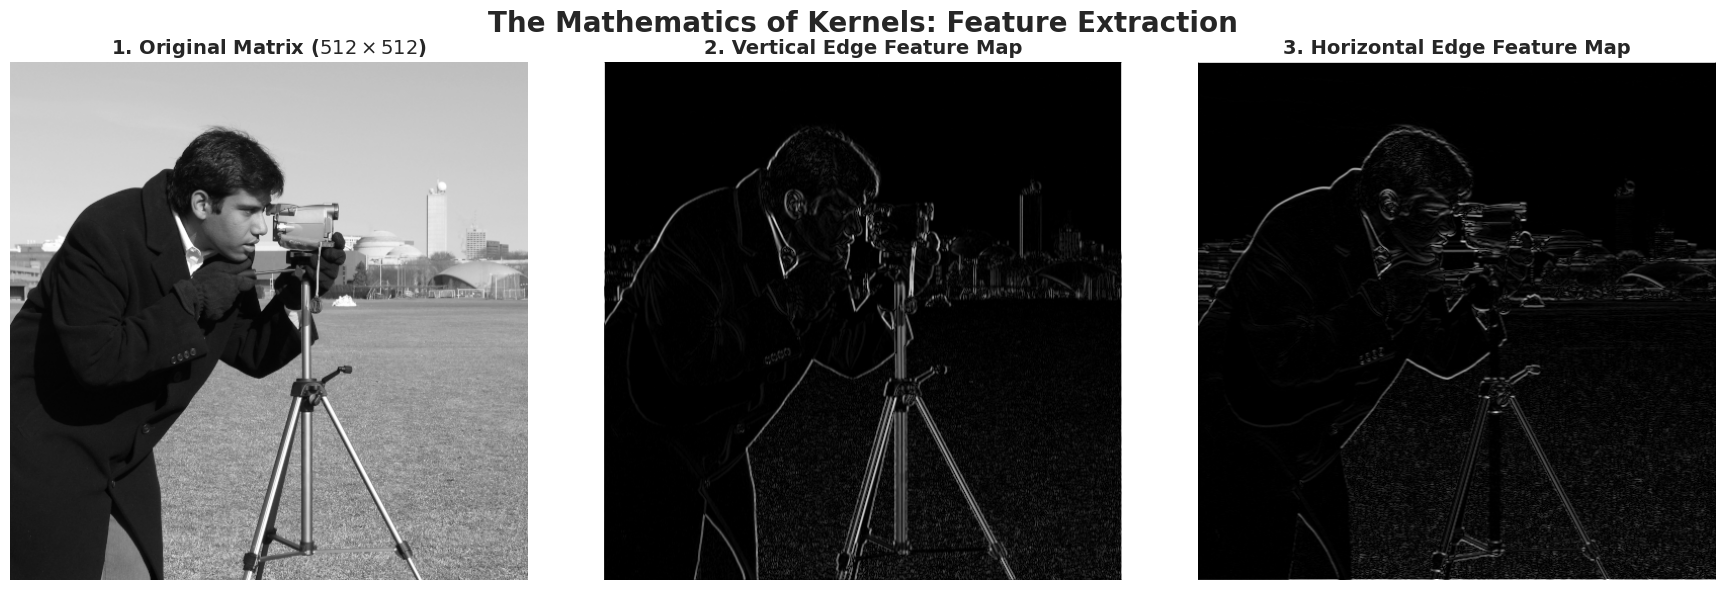

--- 💡 Engineering Insight ---
Look at the mathematical perfection of the kernels. In Plot 2 (Vertical Edges), the tripod legs and the vertical buildings in the background are brightly illuminated, while the horizontal skyline completely vanishes to black (zeros). In Plot 3 (Horizontal Edges), the exact opposite happens: the horizon line shines brightly, but the tripod legs disappear. By sliding a simple 9-number matrix over the image, we have mathematically extracted complex structural features without using 262 million dense weights!


In [4]:
# 1. Fetch and Normalize the Real Image
print("--- 📥 Loading and Formatting Image Tensor ---")
# skimage.data.camera() returns a 512x512 uint8 Grayscale NumPy array
numpy_img = data.camera() 

# Deep Learning Normalization (0-255 -> 0.0-1.0)
normalized_img = numpy_img.astype(np.float32) / 255.0

# PyTorch Convolutions strictly require a 4D Tensor: [Batch, Channels, Height, Width]
# We use .unsqueeze() to artificially add the Batch (1) and Channel (1) dimensions
img_tensor = torch.tensor(normalized_img).unsqueeze(0).unsqueeze(0)

print(f"Input Tensor Shape: {img_tensor.shape} [B, C, H, W]")

# 2. Hardcode Mathematical Kernels (Sobel Filters)
# The Vertical Sobel looks for sharp transitions from Left to Right.
# Look at the math: The left column is negative, the right column is positive.
# If it slides over flat sky, (-1 + 1) cancels out to 0.
# If it slides over a dark edge transitioning to bright, the math triggers a massive spike!
sobel_vertical = torch.tensor([
    [-1.0, 0.0, 1.0],
    [-2.0, 0.0, 2.0],
    [-1.0, 0.0, 1.0]
], dtype=torch.float32)

# The Horizontal Sobel looks for sharp transitions from Top to Bottom.
sobel_horizontal = torch.tensor([
    [-1.0, -2.0, -1.0],
    [ 0.0,  0.0,  0.0],
    [ 1.0,  2.0,  1.0]
], dtype=torch.float32)

# Reshape kernels to match PyTorch requirements: [Out_Channels, In_Channels, H, W]
kernel_v = sobel_vertical.view(1, 1, 3, 3)
kernel_h = sobel_horizontal.view(1, 1, 3, 3)

# 3. Execute the Convolutions!
print("\n--- ⚙️ Executing Spatial Cross-Correlation ---")
# We use F.conv2d. We set padding=1 so a 3x3 kernel maintains the 512x512 resolution.
output_v = F.conv2d(img_tensor, kernel_v, stride=1, padding=1)
output_h = F.conv2d(img_tensor, kernel_h, stride=1, padding=1)

print(f"Output Feature Map Shape: {output_v.shape}")

# Mathematically extract the raw 2D matrices for plotting
# We use torch.abs() because a transition from light-to-dark results in a massive negative number,
# and dark-to-light results in a massive positive. Absolute value shows all edges equally.
edges_v = torch.abs(output_v.squeeze()).numpy()
edges_h = torch.abs(output_h.squeeze()).numpy()

# 4. Visualizing the Mathematical Output
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("The Mathematics of Kernels: Feature Extraction", fontsize=20, fontweight='bold')

# Plot A: Original
axes[0].imshow(normalized_img, cmap='gray')
axes[0].set_title("1. Original Matrix ($512 \\times 512$)", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot B: Vertical Edges
axes[1].imshow(edges_v, cmap='gray')
axes[1].set_title("2. Vertical Edge Feature Map", fontweight='bold', fontsize=14)
axes[1].axis('off')

# Plot C: Horizontal Edges
axes[2].imshow(edges_h, cmap='gray')
axes[2].set_title("3. Horizontal Edge Feature Map", fontweight='bold', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("--- 💡 Engineering Insight ---")
print("Look at the mathematical perfection of the kernels. In Plot 2 (Vertical Edges), the tripod legs and the vertical buildings in the background are brightly illuminated, while the horizontal skyline completely vanishes to black (zeros). In Plot 3 (Horizontal Edges), the exact opposite happens: the horizon line shines brightly, but the tripod legs disappear. By sliding a simple 9-number matrix over the image, we have mathematically extracted complex structural features without using 262 million dense weights!")

## Real-World Use Case or Analogy:

Think of a Convolution like **A Forensic Analyst examining a giant mural in the dark**:

* **The MLP (The Floodlight)**: You turn on a massive floodlight, illuminating the entire $100$-foot mural for exactly 1 second, and try to instantly memorize every single brush stroke simultaneously. Your brain crashes. You learn nothing.
* **The Convolution (The Flashlight/Kernel)**: You turn off the floodlight. You take a small, 1-foot-wide flashlight (The Kernel). You start at the top-left corner of the mural, inspecting a tiny $1 \times 1$ foot patch. You look for one highly specific feature—like a sharp corner. You slide the flashlight 1 inch to the right (Stride), and look again. You methodically scan the entire mural this way.
* **The Result**: By the time you reach the bottom right, you haven't memorized the entire painting, but you have successfully generated a "Feature Map" in your mind of exactly where every single sharp corner is located!